# 01 — Exploratory data analysis and validation\n\nThis notebook performs data quality checks, distribution analysis, and establishes drift detection baselines for the MLOps pipeline. We validate the training data against the expected schema and inspect feature distributions that will later be monitored in production.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_DIR)

from src.data_loader import (
    load_training_data, load_drift_data, validate_schema,
    validate_nulls, validate_distributions, run_all_validations,
    EXPECTED_SCHEMA, EXPECTED_COLUMNS,
)

## Load datasets

In [2]:
data_dir = os.path.join(PROJECT_DIR, "data")
train_df, test_df = load_training_data(data_dir)

# drift.csv doesn't exist; generate it using the synthetic data generator
drift_path = os.path.join(data_dir, "drift.csv")
if not os.path.exists(drift_path):
    from src.data_loader import generate_synthetic_churn_data
    drift_df = generate_synthetic_churn_data(n_samples=1000, drift=True, seed=99)
    drift_df.to_csv(drift_path, index=False)
    print(f"Generated drift data at {drift_path}")
else:
    drift_df = load_drift_data(data_dir)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Drift: {drift_df.shape}")

Train: (5000, 20)
Test:  (1500, 20)
Drift: (2000, 20)


In [3]:
train_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,No,8,Yes,No phone service,DSL,No,Yes,Yes,No,Yes,No,Two year,No,Electronic check,29.54,331.75,0
1,Female,0,No,Yes,10,Yes,Yes,DSL,No,Yes,No,No,Yes,No,Month-to-month,No,Mailed check,61.59,595.50,1
2,Male,0,Yes,Yes,72,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Electronic check,95.81,6866.09,0
3,Male,1,Yes,No,2,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,77.41,141.93,0
4,Male,0,No,No,30,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),81.70,2451.38,0


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5000 non-null   object 
 1   SeniorCitizen     5000 non-null   int64  
 2   Partner           5000 non-null   object 
 3   Dependents        5000 non-null   object 
 4   tenure            5000 non-null   int64  
 5   PhoneService      5000 non-null   object 
 6   MultipleLines     5000 non-null   object 
 7   InternetService   5000 non-null   object 
 8   OnlineSecurity    5000 non-null   object 
 9   OnlineBackup      5000 non-null   object 
 10  DeviceProtection  5000 non-null   object 
 11  TechSupport       5000 non-null   object 
 12  StreamingTV       5000 non-null   object 
 13  StreamingMovies   5000 non-null   object 
 14  Contract          5000 non-null   object 
 15  PaperlessBilling  5000 non-null   object 
 16  PaymentMethod     5000 non-null   object 


## Schema validation\n\nVerify that columns, dtypes, and null rates match the expected schema defined in `data_loader.py`.

In [5]:
schema_result = validate_schema(train_df)
null_result = validate_nulls(train_df)

print("Schema validation:", schema_result.summary())
print("Null validation:", null_result.summary())
print()

# Show any failures
for check in schema_result.to_dict() + null_result.to_dict():
    if not check["passed"]:
        print(f"  FAIL: {check['check']} — {check['detail']}")

Schema validation: 22/22 checks passed
Null validation: 20/20 checks passed



In [6]:
# Full validation report
full_result = run_all_validations(train_df)
val_df = pd.DataFrame(full_result.to_dict())
print(f"Overall: {full_result.summary()}")
val_df[val_df["passed"] == False]

Overall: 45/45 checks passed


,check,passed,detail


## Target distribution

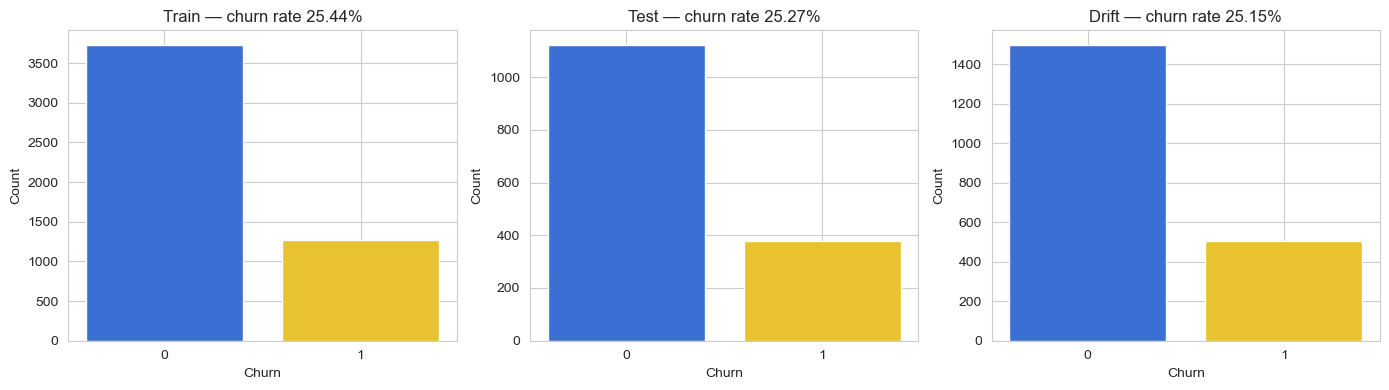

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [("Train", train_df), ("Test", test_df), ("Drift", drift_df)]):
    counts = df["Churn"].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=["#3B6FD4", "#E8C230"])
    ax.set_title(f"{name} — churn rate {df['Churn'].mean():.2%}")
    ax.set_xlabel("Churn")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Numeric feature distributions\n\nCompare training and drift data distributions side by side. The drift dataset has shifted distributions in tenure, MonthlyCharges, and contract mix.

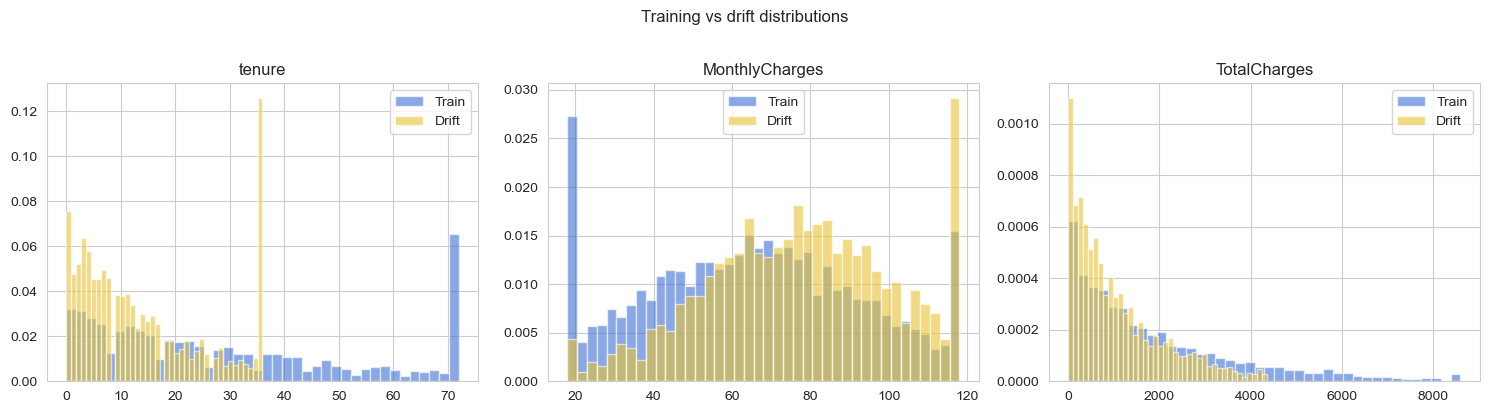

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(train_df[col], bins=40, alpha=0.6, color="#3B6FD4", label="Train", density=True)
    ax.hist(drift_df[col], bins=40, alpha=0.6, color="#E8C230", label="Drift", density=True)
    ax.set_title(col)
    ax.legend()
plt.suptitle("Training vs drift distributions", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Summary statistics comparison
summary = pd.concat([
    train_df[numeric_cols].describe().T.add_prefix("train_"),
    drift_df[numeric_cols].describe().T.add_prefix("drift_"),
], axis=1)
summary[["train_mean", "drift_mean", "train_std", "drift_std"]]

,train_mean,drift_mean,train_std,drift_std
tenure,29.110400,13.849500,23.303846,11.654131
MonthlyCharges,64.993924,77.383290,27.094656,23.772378
TotalCharges,1880.710886,1070.029125,1808.465334,992.275944


## Categorical feature distributions

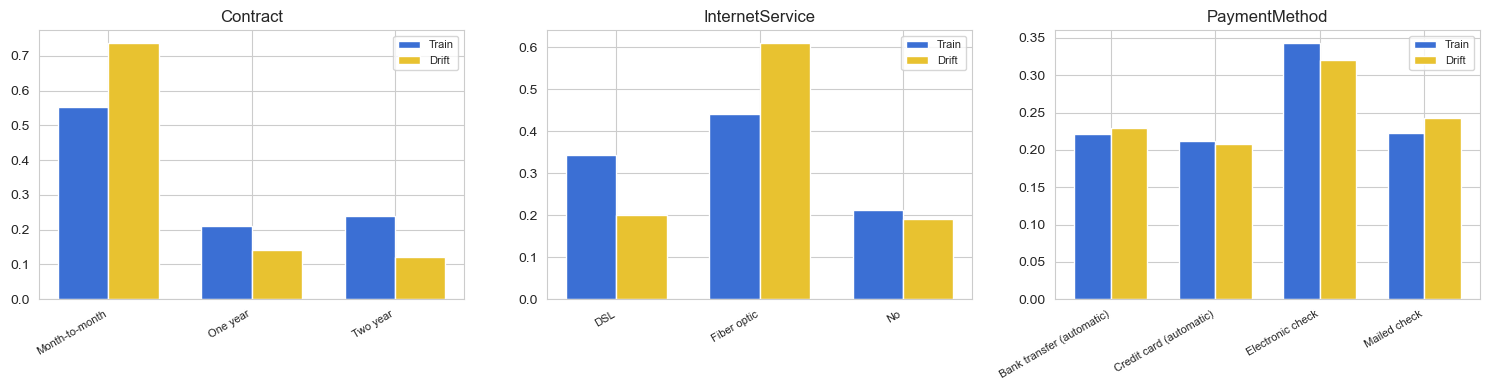

In [10]:
cat_cols = ["Contract", "InternetService", "PaymentMethod"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    train_pct = train_df[col].value_counts(normalize=True).sort_index()
    drift_pct = drift_df[col].value_counts(normalize=True).sort_index()
    x = np.arange(len(train_pct))
    w = 0.35
    ax.bar(x - w/2, train_pct.values, w, label="Train", color="#3B6FD4")
    ax.bar(x + w/2, drift_pct.reindex(train_pct.index, fill_value=0).values, w, label="Drift", color="#E8C230")
    ax.set_xticks(x)
    ax.set_xticklabels(train_pct.index, rotation=30, ha="right", fontsize=8)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Drift detection baseline (PSI)\n\nCompute PSI between training and drift data to establish the monitoring baseline. This will be used in production to decide when retraining is needed.

In [11]:
from src.model import compute_psi

psi_scores = compute_psi(train_df, drift_df)
psi_df = pd.DataFrame([
    {"Feature": k, "PSI": round(v, 4),
     "Status": "Significant shift" if v > 0.25 else ("Moderate shift" if v > 0.10 else "No shift")}
    for k, v in sorted(psi_scores.items(), key=lambda x: -x[1])
])
psi_df

,Feature,PSI,Status
0,tenure,1.9195,Significant shift
1,TotalCharges,0.6228,Significant shift
2,MonthlyCharges,0.2794,Significant shift
3,SeniorCitizen,0.0023,No shift
4,Churn,0.0000,No shift


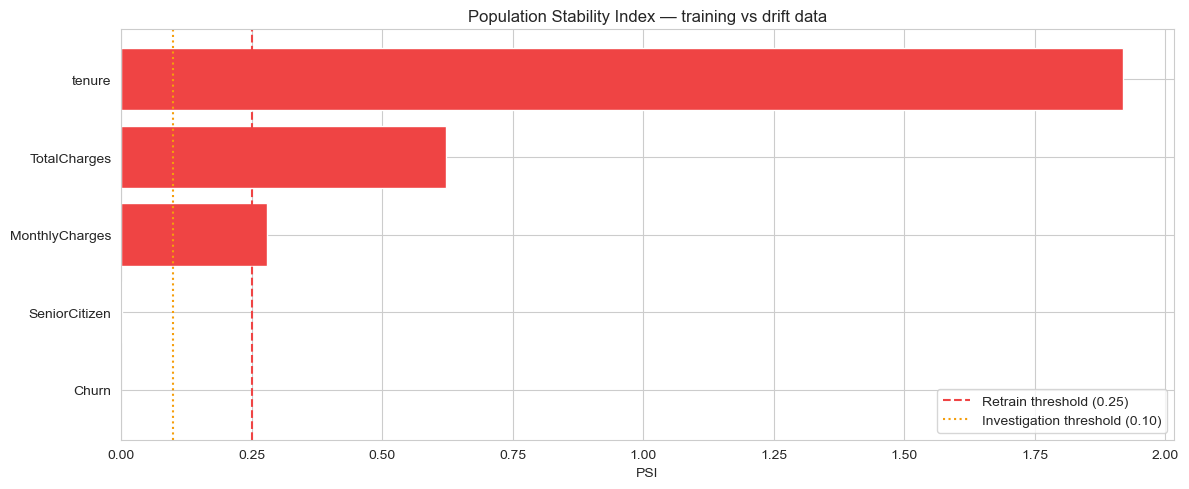

In [12]:
colors = ["#ef4444" if v > 0.25 else "#f59e0b" if v > 0.10 else "#22c55e" for v in psi_df["PSI"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(psi_df["Feature"], psi_df["PSI"], color=colors)
ax.axvline(x=0.25, color="#ef4444", linestyle="--", label="Retrain threshold (0.25)")
ax.axvline(x=0.10, color="#f59e0b", linestyle=":", label="Investigation threshold (0.10)")
ax.set_xlabel("PSI")
ax.set_title("Population Stability Index — training vs drift data")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Correlation analysis

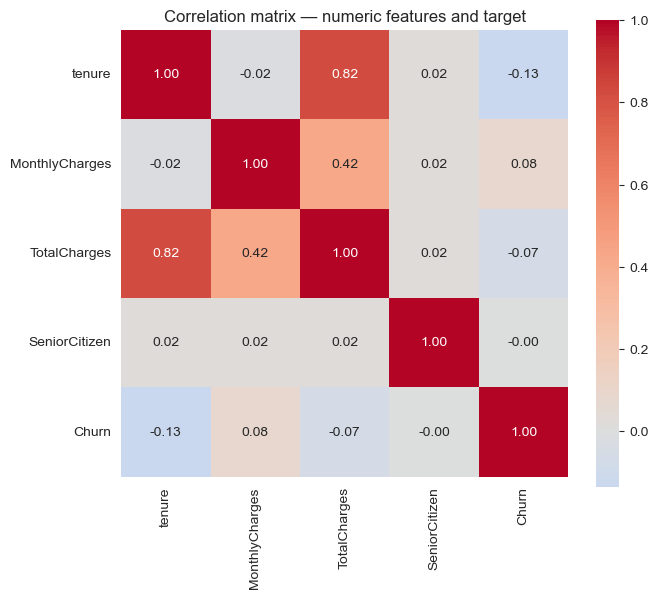

In [13]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
corr = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation matrix — numeric features and target")
plt.tight_layout()
plt.show()

## Summary\n\n- All schema and null checks pass on the training data\n- The drift dataset shows clear shifts in tenure (lower), MonthlyCharges (higher), and contract mix (more month-to-month)\n- PSI scores confirm significant drift in multiple features, validating the monitoring approach\n- These baselines will be used by the pipeline to trigger automated retraining when PSI exceeds 0.25